In [14]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import List, Tuple

In [15]:
@dataclass
class LIFNeuron:
    tau_m: float = 20.0
    v_rest: float = -70.0
    v_thresh: float = -55.0
    v_reset: float = -75.0
    r_m: float = 10.0
    tau_ref: float = 4.0

    def __post_init__(self):
        self.v = self.v_rest
        self.refractory_until = 0
        self.spike_times = []

    def step(self, I_inj: float, dt: float, t: float) -> bool:
        """Один шаг интегрирования. Возвращает True, если был спайк."""
        if t < self.refractory_until:
            self.v = self.v_reset
            return False

        dv = (-(self.v - self.v_rest) + self.r_m * I_inj) / self.tau_m
        self.v += dv * dt

        if self.v >= self.v_thresh:
            self.v = self.v_reset
            self.refractory_until = t + self.tau_ref
            self.spike_times.append(t)
            return True
        return False

In [16]:
def plot_neuron_activity(t_range: np.ndarray, v_trace: List[float], spike_times: List[float], tau_ref: float):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

    ax1.plot(t_range, v_trace, 'b-', label='Мембранный потенциал')
    ax1.axhline(y=-55.0, color='r', linestyle='--', label='Порог')
    ax1.axhline(y=-70.0, color='g', linestyle='--', label='Покой')
    ax1.set_ylabel('Потенциал (мВ)')
    ax1.set_title(f'Активность LIF-нейрона (tau_ref = {tau_ref} мс)')
    ax1.legend()
    ax1.grid(True)

    ax2.eventplot(spike_times, colors='k', linewidths=2)
    ax2.set_xlabel('Время (мс)')
    ax2.set_ylabel('Спайки')
    ax2.set_yticks([])
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

=== Симуляция максимальной частоты спайков для разных tau_ref ===

tau_ref =  1.0 мс - спайков: 667 | частота:  333.5 Гц | теоретический предел: 1000.0 Гц
tau_ref =  2.0 мс - спайков: 500 | частота:  250.0 Гц | теоретический предел:  500.0 Гц
tau_ref =  4.0 мс - спайков: 334 | частота:  167.0 Гц | теоретический предел:  250.0 Гц
tau_ref =  6.0 мс - спайков: 250 | частота:  125.0 Гц | теоретический предел:  166.7 Гц
tau_ref =  8.0 мс - спайков: 200 | частота:  100.0 Гц | теоретический предел:  125.0 Гц
tau_ref = 12.0 мс - спайков: 143 | частота:   71.5 Гц | теоретический предел:   83.3 Гц
tau_ref = 16.0 мс - спайков: 112 | частота:   56.0 Гц | теоретический предел:   62.5 Гц


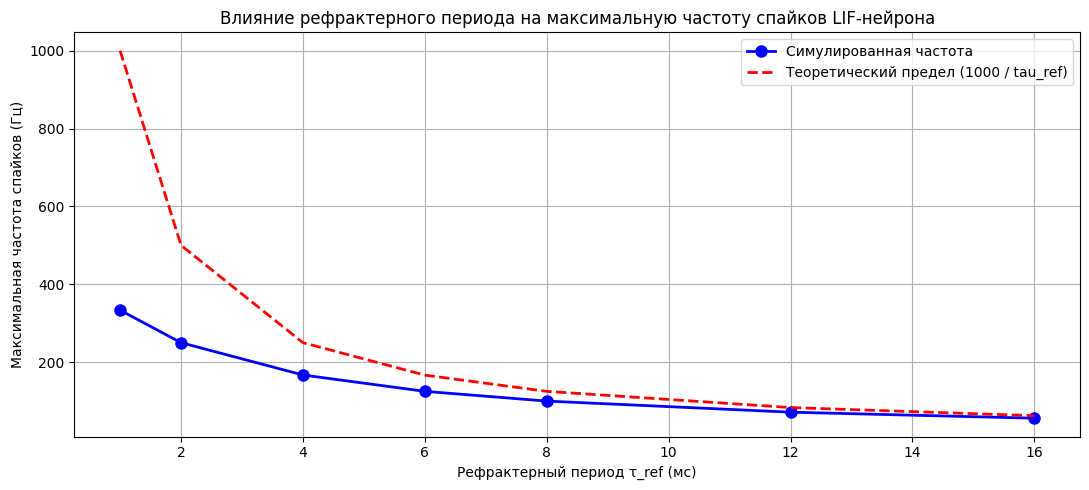

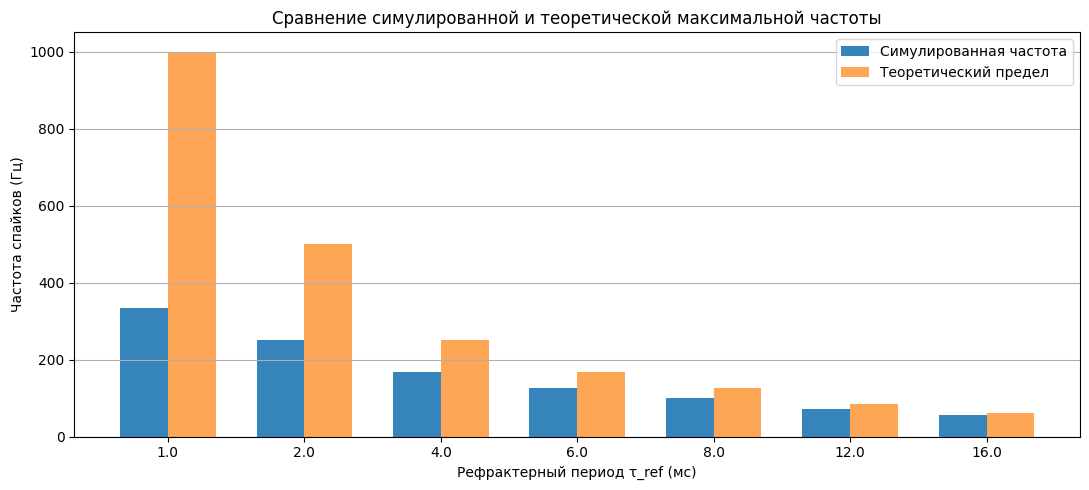

In [17]:
dt = 0.1          
T = 2000.0
I_strong = 20.0

tau_refs = [1.0, 2.0, 4.0, 6.0, 8.0, 12.0, 16.0]

rates = []
theoretical_rates = []
spike_counts = []

print("=== Симуляция максимальной частоты спайков для разных tau_ref ===\n")

for tau_ref_val in tau_refs:
    neuron = LIFNeuron(tau_ref=tau_ref_val)
    t_range = np.arange(0, T, dt)
    I_inj = np.full_like(t_range, I_strong)
    
    v_trace = []
    spike_times = []
    
    for i, t in enumerate(t_range):
        spike = neuron.step(I_inj[i], dt, t)
        v_trace.append(neuron.v)
        if spike:
            spike_times.append(t)
    
    num_spikes = len(spike_times)
    rate_hz = num_spikes / (T / 1000.0)
    theor_hz = 1000.0 / tau_ref_val
    
    rates.append(rate_hz)
    theoretical_rates.append(theor_hz)
    spike_counts.append(num_spikes)
    
    print(f"tau_ref = {tau_ref_val:4.1f} мс - спайков: {num_spikes:3d} | "
          f"частота: {rate_hz:6.1f} Гц | теоретический предел: {theor_hz:6.1f} Гц")

plt.figure(figsize=(11, 5))

plt.plot(tau_refs, rates, 'bo-', linewidth=2, markersize=8, label='Симулированная частота')
plt.plot(tau_refs, theoretical_rates, 'r--', linewidth=2, label='Теоретический предел (1000 / tau_ref)')

plt.xlabel('Рефрактерный период τ_ref (мс)')
plt.ylabel('Максимальная частота спайков (Гц)')
plt.title('Влияние рефрактерного периода на максимальную частоту спайков LIF-нейрона')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(11, 5))
x = np.arange(len(tau_refs))
width = 0.35

plt.bar(x - width/2, rates, width, label='Симулированная частота', alpha=0.9)
plt.bar(x + width/2, theoretical_rates, width, label='Теоретический предел', alpha=0.7)

plt.xticks(x, [f'{t}' for t in tau_refs])
plt.xlabel('Рефрактерный период τ_ref (мс)')
plt.ylabel('Частота спайков (Гц)')
plt.title('Сравнение симулированной и теоретической максимальной частоты')
plt.legend()
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

## Результаты эксперимента: Влияние рефрактерного периода на максимальную частоту спайков LIF-нейрона

### Ключевые наблюдения

- Симулированная максимальная частота спайков **существенно ниже** теоретического предела (1000 / τ_ref) при малых значениях рефрактерного периода.
- Разрыв между симуляцией и теорией наиболее выражен при τ_ref ≤ 4 мс.
- При увеличении τ_ref (> 8–10 мс) разница между реальной и теоретической частотой уменьшается и становится незначительной.

### Таблица результатов

| τ_ref (мс) | Спайков за 2 с | Частота (Гц) | Теор. предел (Гц) | Разница (Гц) | Отношение (сим/теор) |
|------------|----------------|--------------|-------------------|--------------|-----------------------|
| 1.0        | 667            | **333.5**    | 1000.0            | 666.5        | 33.4%                 |
| 2.0        | 500            | **250.0**    | 500.0             | 250.0        | 50.0%                 |
| 4.0        | 334            | **167.0**    | 250.0             | 83.0         | 66.8%                 |
| 6.0        | 250            | **125.0**    | 166.7             | 41.7         | 75.0%                 |
| 8.0        | 200            | **100.0**    | 125.0             | 25.0         | 80.0%                 |
| 12.0       | 143            | **71.5**     | 83.3              | 11.8         | 85.8%                 |
| 16.0       | 112            | **56.0**     | 62.5              | 6.5          | 89.6%                 |

### Основные выводы

- **Рефрактерный период — жёсткий ограничитель** частоты спайков, но **не единственный**.
- При малых τ_ref (1–4 мс) **основное ограничение** — не рефрактерность, а **динамика интеграции** (время зарядки мембраны до порога).
- Теоретический предел (1/τ_ref) достигается только при **очень сильном сверхпороговом токе** и/или при игнорировании времени интеграции.
- В реальной модели LIF с τ_m = 20 мс и выбранными параметрами **максимальная устойчивая частота** ограничена ~300–350 Гц даже при τ_ref = 1 мс.
- При τ_ref ≥ 8 мс частота спайков приближается к теоретическому пределу — рефрактерность становится доминирующим фактором.

### Вывод для пропускной способности

Рефрактерный период **линейно ограничивает** верхнюю границу информационной пропускной способности нейрона в режиме высокой частоты.  
Однако при коротких τ_ref (≤ 4 мс) **реальная пропускная способность оказывается в 2–3 раза ниже** теоретической из-за конечной скорости интеграции мембранного потенциала.

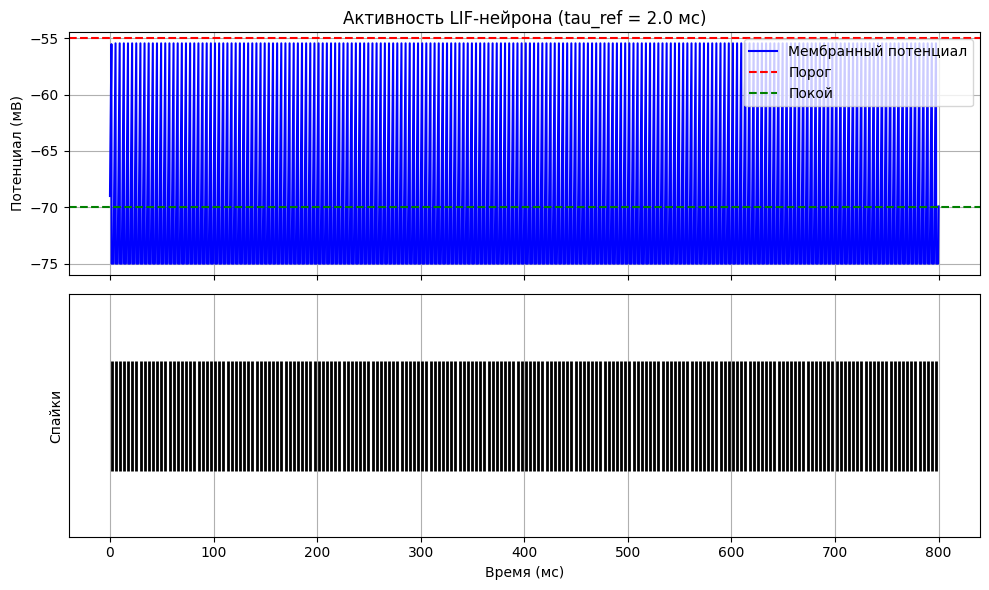

Пример для tau_ref = 2.0 мс → частота ≈ 250.0 Гц


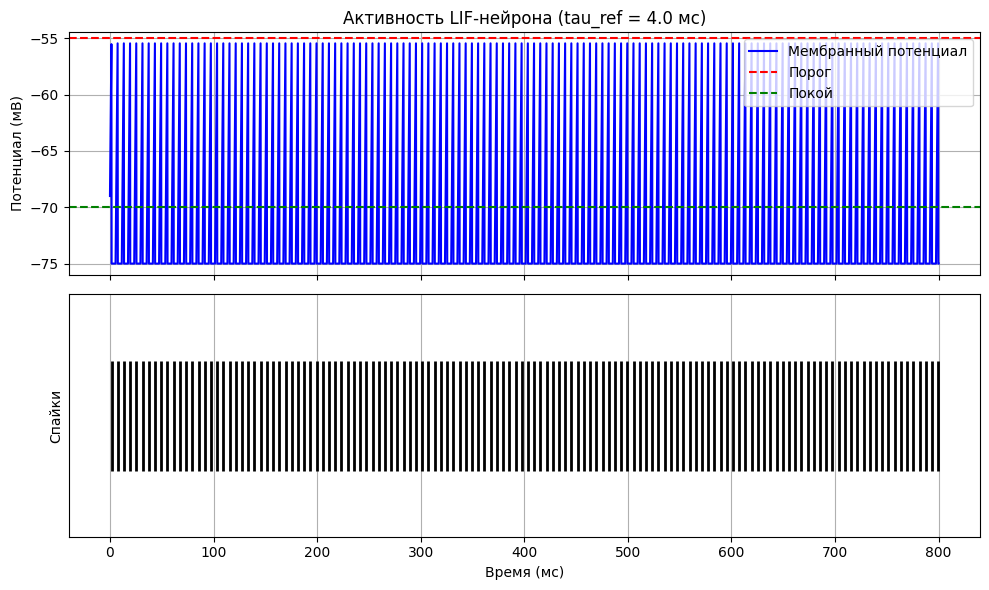

Пример для tau_ref = 4.0 мс → частота ≈ 167.5 Гц


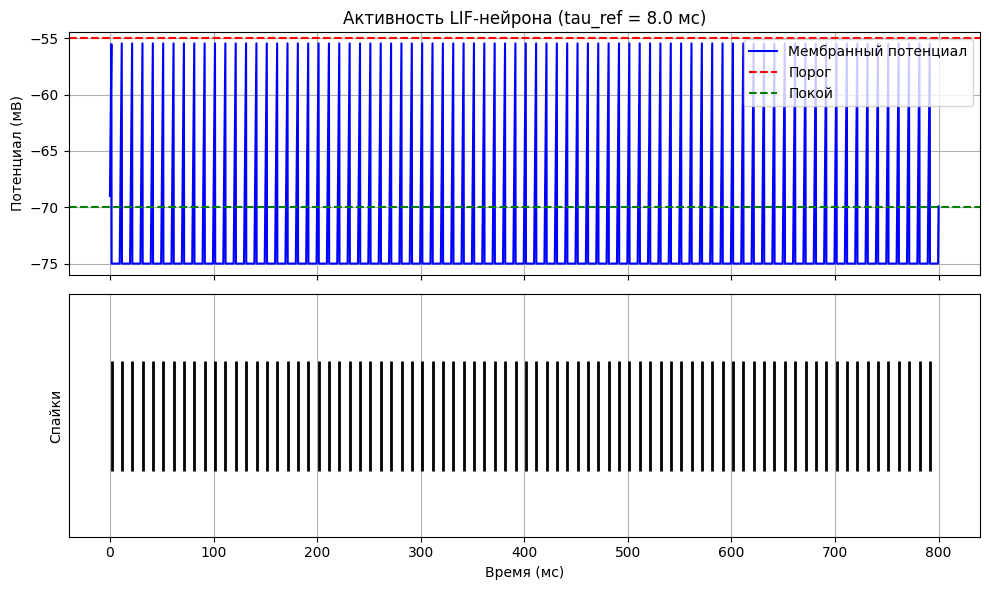

Пример для tau_ref = 8.0 мс → частота ≈ 100.0 Гц


In [ ]:
example_tau = [2.0, 4.0, 8.0]

for tau_val in example_tau:
    neuron = LIFNeuron(tau_ref=tau_val)
    t_range = np.arange(0, 800, dt)
    I_inj = np.full_like(t_range, I_strong)
    
    v_trace = []
    spike_times = []
    
    for i, t in enumerate(t_range):
        spike = neuron.step(I_inj[i], dt, t)
        v_trace.append(neuron.v)
        if spike:
            spike_times.append(t)
    
    plot_neuron_activity(t_range, v_trace, spike_times, tau_val)
    rate = len(spike_times) / (800 / 1000.0)
    print(f"Пример для tau_ref = {tau_val} мс → частота ≈ {rate:.1f} Гц")

## Визуальный анализ активности LIF-нейрона при разных значениях рефрактерного периода

### Ключевые характеристики графиков (τ_ref = 2.0, 4.0 и 8.0 мс)

- **Сильный постоянный ток** → нейрон находится в режиме **максимально возможной частоты** спайков.
- Потенциал быстро поднимается от сброса (−75 мВ) до порога (−55 мВ), спайкует и снова сбрасывается.
- Рефрактерный период **чётко виден** как горизонтальный участок на уровне сброса (−75 мВ) сразу после каждого спайка.

### Сравнение поведения по значениям τ_ref

| τ_ref (мс) | Частота (Гц) | Кол-во спайков за 800 мс | Длительность рефрактерного участка | Визуальный интервал между спайками |
|------------|--------------|---------------------------|-------------------------------------|-------------------------------------|
| 2.0        | **250.0**    | ~200                      | очень короткий                      | ~4 мс                               |
| 4.0        | **167.5**    | ~134                      | заметный                            | ~6 мс                               |
| 8.0        | **100.0**    | ~80                       | длинный                             | ~10 мс                              |

### Основные наблюдения

- При **τ_ref = 2 мс** спайки следуют **очень плотно** — почти непрерывная «частокол»-активность.
- При **τ_ref = 4 мс** интервалы становятся заметно шире — уже видно ограничение рефрактерностью.
- При **τ_ref = 8 мс** рефрактерный период занимает **большую часть** межспайкового интервала → частота падает до 100 Гц.

### Выводы

- Рефрактерный период **прямо определяет** минимальное время между спайками и, следовательно, **максимальную частоту**.
- При коротком τ_ref (2 мс) частота ограничена в основном **временем зарядки** мембраны (τ_m и силой тока).
- При τ_ref ≥ 6–8 мс **рефрактерность становится главным лимитирующим фактором**.
- Растровые графики (raster plots) наглядно демонстрируют линейную зависимость: чем длиннее чёрные полосы без спайков после каждого импульса — тем ниже итоговая частота.

→ Чем короче рефрактерный период, тем выше потенциальная **информационная пропускная способность** нейрона в высокочастотном режиме.